In [1]:
# Import libraries
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Load IMDB dataset
num_words = 10000
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words)

In [2]:
# Vectorize sequences (convert to binary matrix)
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

x_train = vectorize_sequences(x_train)
x_test = vectorize_sequences(x_test)

# Convert labels to float
y_train = np.asarray(y_train).astype("float32")
y_test = np.asarray(y_test).astype("float32")

# Create validation set
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

# Build model
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=10,
    batch_size=512,
    validation_data=(x_val, y_val)
)

/Users/avartanathlay/my_jupyter_env/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7763 - loss: 0.5508 - val_accuracy: 0.8550 - val_loss: 0.4082
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8995 - loss: 0.3092 - val_accuracy: 0.8817 - val_loss: 0.3049
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9292 - loss: 0.2135 - val_accuracy: 0.8886 - val_loss: 0.2787
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9470 - loss: 0.1619 - val_accuracy: 0.8850 - val_loss: 0.2849
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9629 - loss: 0.1257 - val_accuracy: 0.8863 - val_loss: 0.2901
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9731 - loss: 0.0984 - val_accuracy: 0.8819 - val_loss: 0.3084
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9819 - loss: 0.0770 - val_accuracy: 0.8799 - val_loss: 0.3292
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9883 - loss: 0.0606 - val_accuracy: 0.8781 - val_loss

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - accuracy: 0.8631 - loss: 0.4376
Test Loss, Test Accuracy: [0.43759867548942566, 0.8630800247192383]


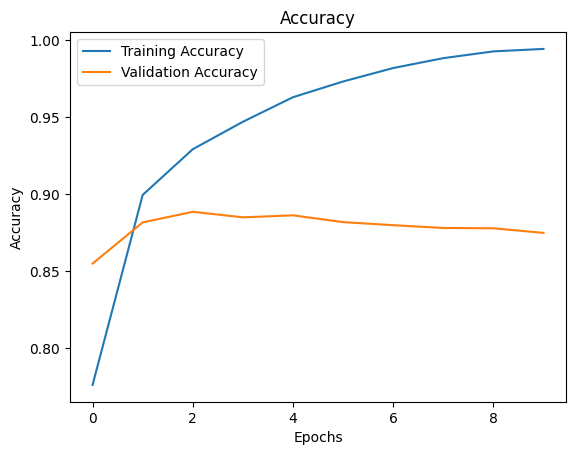

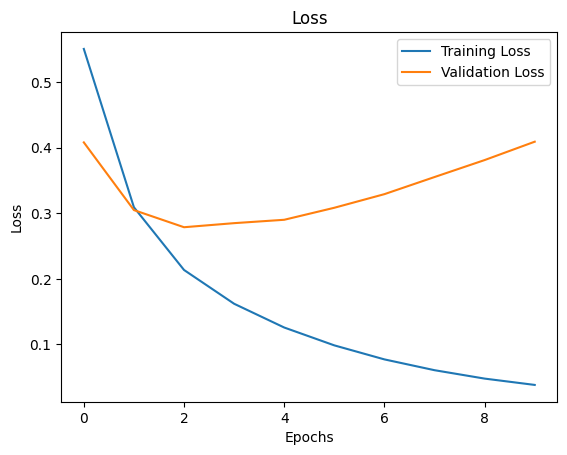

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Sample Predictions: [[0.06493033]
 [0.9999812 ]
 [0.9202022 ]
 [0.9447352 ]
 [0.9797555 ]]


In [3]:
# Evaluate model
results = model.evaluate(x_test, y_test)
print("Test Loss, Test Accuracy:", results)

# Plot accuracy and loss
history_dict = history.history

# Accuracy plot
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Predictions
predictions = model.predict(x_test[:5])
print("Sample Predictions:", predictions)